In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.72 s (started: 2026-07-17 01:35:12 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    save_path="./scarf_datasets",
    as_zarr=True,
)

time: 20.1 s (started: 2026-07-17 01:35:14 +02:00)


In [3]:
ds = scarf.DataStore(
    "scarf_datasets/bastidas-ponce_4K_pancreas-d15_rnaseq/data.zarr",
    nthreads=4,
    default_assay="RNA",
)

time: 316 ms (started: 2026-07-17 01:35:32 +02:00)


In [4]:
ds

DataStore has 3413 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_G2M_score', 
            'RNA_percentMito', 'RNA_percentRibo', 'RNA_cell_cycle_phase', 'RNA_nFeatures', 'RNA_nCounts', 
            'clusters_coarse', 'RNA_cluster', 'RNA_UMAP2', 'RNA_S_score', 'S_score', 
            'clusters', 'RNA_UMAP1'
   RNA assay has 12497 (27998) features and following metadata:
            'I', 'ids', 'names', 'highly_variable_genes', 'nCells', 
            'I__hvgs', 'dropOuts'

time: 137 ms (started: 2026-07-17 01:35:33 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


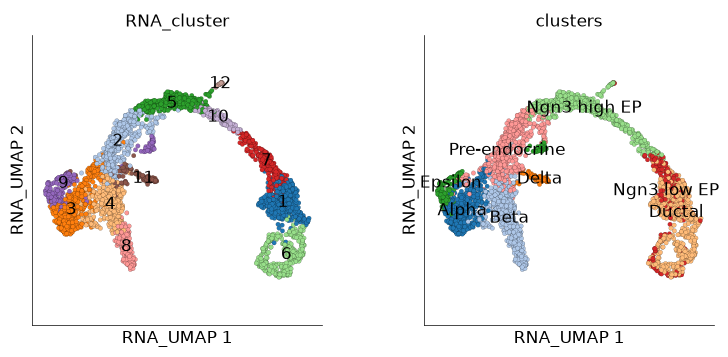

time: 1.51 s (started: 2026-07-17 01:35:33 +02:00)


In [5]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by=["RNA_cluster", "clusters"],
    width=4,
    height=4,
    legend_onside=False,
    cmap="tab20",
)

In [6]:
ds.run_pseudotime_scoring(
    source_sink_key="RNA_cluster",  # Column that contains cluster information
    sources=[1],  # Source clusters
    sinks=[3],  # Sink clusters
)

Calculating SVD of graph laplacian. This might take a while...



time: 1.54 s (started: 2026-07-17 01:35:34 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


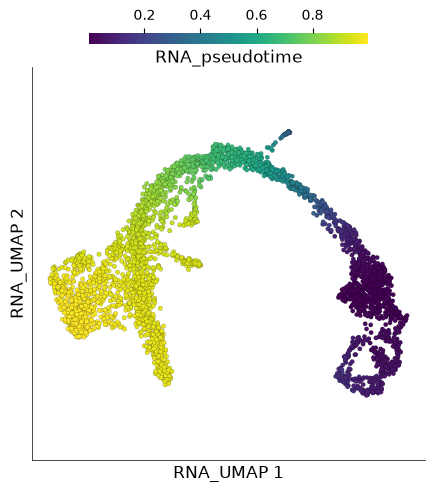

time: 1.05 s (started: 2026-07-17 01:35:36 +02:00)


In [7]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by="RNA_pseudotime",
)

In [8]:
ds.run_pseudotime_marker_search(pseudotime_key="RNA_pseudotime")

time: 24.6 s (started: 2026-07-17 01:35:37 +02:00)


In [9]:
ds.RNA.feats.head()

,I,ids,names,I__RNA_pseudotime__r,nCells,highly_variable_genes,I__hvgs,dropOuts,I__RNA_pseudotime__p
0,False,Xkr4,Xkr4,NaN,6,False,False,3690,NaN
1,False,Gm37381,Gm37381,NaN,0,True,False,3696,NaN
2,False,Rp1,Rp1,NaN,0,True,False,3696,NaN
3,False,Rp1-1,Rp1-1,NaN,0,True,False,3696,NaN
4,False,Sox17,Sox17,NaN,0,True,False,3696,NaN


time: 442 ms (started: 2026-07-17 01:36:00 +02:00)


In [10]:
corr_genes_df = ds.RNA.feats.to_pandas_dataframe(
    columns=["names", "I__RNA_pseudotime__p", "I__RNA_pseudotime__r"], key="I"
)

# Rename the columns to be shorter
corr_genes_df.columns = ["names", "p_value", "r_value"]

time: 268 ms (started: 2026-07-17 01:36:00 +02:00)


In [11]:
corr_genes_df.sort_values("r_value")[:15]

,names,p_value,r_value
18864,Spp1,0.0,-0.853747
22385,Rps19,0.0,-0.811618
24581,Rpl13,0.0,-0.808717
431,Dbi,0.0,-0.801796
16254,Rps8,0.0,-0.787065
19815,Rpl32,0.0,-0.777364
3163,Sparc,0.0,-0.775107
26498,Rps4x,0.0,-0.768438
20787,Mgst1,0.0,-0.762069
13425,Rpl12,0.0,-0.754217


time: 11.7 ms (started: 2026-07-17 01:36:00 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


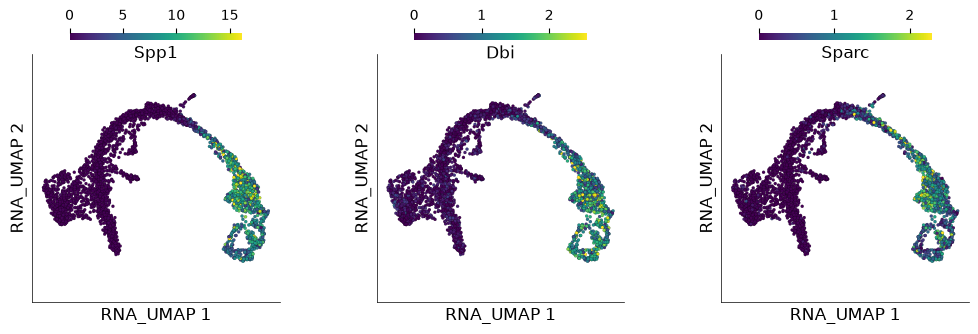

time: 2.68 s (started: 2026-07-17 01:36:00 +02:00)


In [12]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by=["Spp1", "Dbi", "Sparc"],
    width=3.5,
    height=3.5,
    point_size=5,
)

In [13]:
corr_genes_df.sort_values("r_value", ascending=False)[:10]

,names,p_value,r_value
21244,Aplp1,0.000000e+00,0.717088
14296,Gnas,0.000000e+00,0.708386
23549,Cpe,0.000000e+00,0.703213
3186,Fam183b,0.000000e+00,0.642701
25060,Hmgn3,0.000000e+00,0.614297
26573,Bex2,0.000000e+00,0.608843
8171,Tuba1a,0.000000e+00,0.594564
26730,Pcsk1n,0.000000e+00,0.593595
4284,Ubb,1.342275e-303,0.578068
2189,Rap1b,6.955857e-291,0.568015


time: 13.3 ms (started: 2026-07-17 01:36:03 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


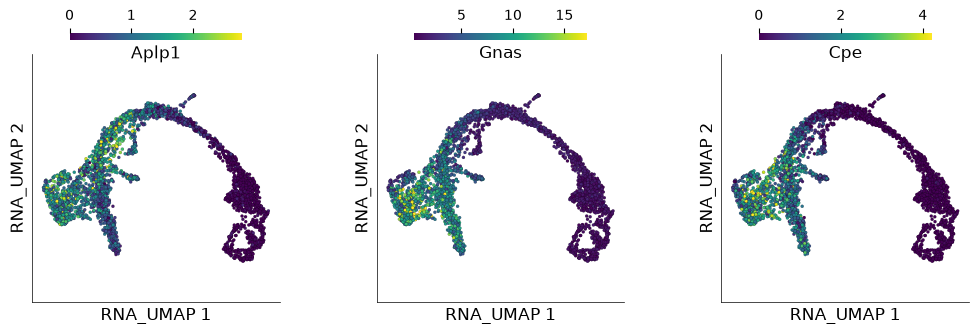

time: 2.76 s (started: 2026-07-17 01:36:03 +02:00)


In [14]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by=["Aplp1", "Gnas", "Cpe"],
    width=3.5,
    height=3.5,
    point_size=5,
)

In [15]:
ds.run_pseudotime_aggregation(
    pseudotime_key="RNA_pseudotime",
    cluster_label="pseudotime_clusters",
    n_clusters=15,
    window_size=200,
    chunk_size=100,
)

Performing clustering, this might take a while...



time: 34.6 s (started: 2026-07-17 01:36:06 +02:00)


In [16]:
# The binned data matrix. Here we print the shape of the matrix indicating the number of features and numner of bins respectively
ds.RNA.z["aggregated_I_I_RNA_pseudotime/data"].shape

(12497, 100)

time: 11.3 ms (started: 2026-07-17 01:36:39 +02:00)


In [17]:
# Fetching pseudotime based cluster identity of features
ds.RNA.feats.fetch("pseudotime_clusters")

array([ 7, 13,  4, ...,  8, 11, 14], shape=(12497,))

time: 131 ms (started: 2026-07-17 01:36:39 +02:00)


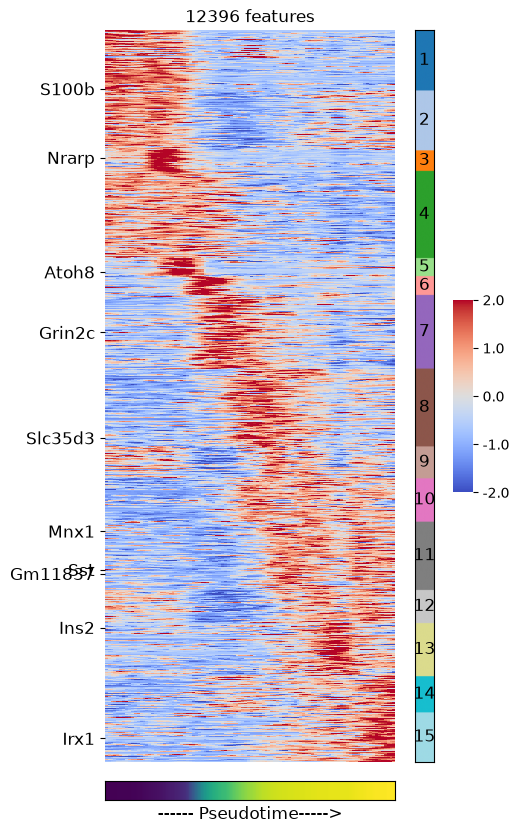

time: 5.67 s (started: 2026-07-17 01:36:39 +02:00)


In [18]:
# Highlighting some marker genes
genes_to_label = [
    "S100b",
    "Nrarp",
    "Atoh8",
    "Grin2c",
    "Slc35d3",
    "Sst",
    "Mnx1",
    "Ins2",
    "Gm11837",
    "Irx1",
]

ds.plot_pseudotime_heatmap(
    cell_key="I",
    feat_key="I",
    feature_cluster_key="pseudotime_clusters",
    pseudotime_key="RNA_pseudotime",
    show_features=genes_to_label,
)

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


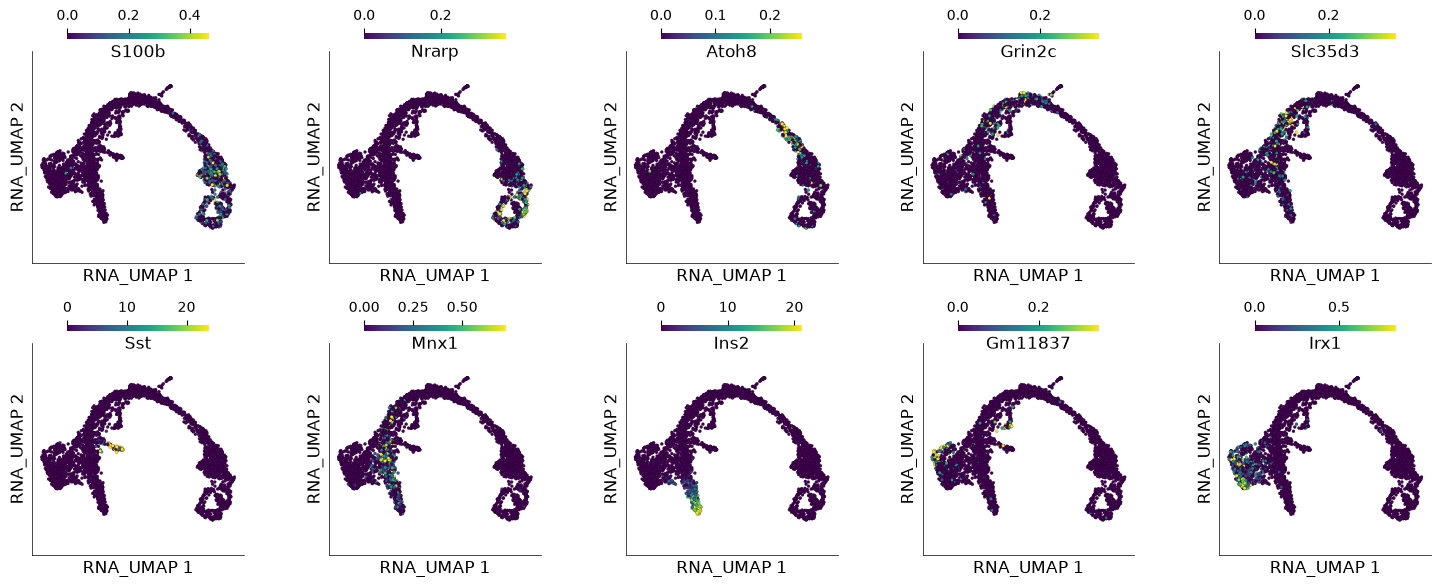

time: 11.8 s (started: 2026-07-17 01:36:45 +02:00)


In [19]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by=genes_to_label,
    width=3,
    height=3,
    point_size=5,
    n_columns=5,
)

In [20]:
ds.add_grouped_assay(group_key="pseudotime_clusters", assay_label="PTIME_MODULES")

time: 10.3 s (started: 2026-07-17 01:36:57 +02:00)


In [21]:
# DataStore summary showing `PTIME_MODULES` assay with 15 features (number of pseudotime based feature clusters)
ds

DataStore has 3413 (3696) cells with 2 assays: RNA PTIME_MODULES
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_G2M_score', 
            'RNA_percentMito', 'PTIME_MODULES_nCounts', 'RNA_pseudotime', 'RNA_pseudotime__valid', 'RNA_nFeatures', 
            'RNA_cell_cycle_phase', 'RNA_percentRibo', 'RNA_nCounts', 'clusters_coarse', 'RNA_S_score', 
            'RNA_cluster', 'RNA_UMAP2', 'PTIME_MODULES_nFeatures', 'S_score', 'clusters', 
            'RNA_UMAP1'
   RNA assay has 12497 (27998) features and following metadata:
            'I', 'ids', 'names', 'I__RNA_pseudotime__r', 'nCells', 
            'highly_variable_genes', 'I__hvgs', 'dropOuts', 'I__RNA_pseudotime__p', 'pseudotime_clusters', 
          
   PTIME_MODULES assay has 15 (15) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 454 ms (started: 2026-07-17 01:37:05 +02:00)


In [22]:
ds.PTIME_MODULES.feats.head()

,I,ids,names,nCells,dropOuts
0,True,group_1,group_1,3696,0
1,True,group_2,group_2,3696,0
2,True,group_3,group_3,3696,0
3,True,group_4,group_4,3696,0
4,True,group_5,group_5,3696,0


time: 128 ms (started: 2026-07-17 01:37:06 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


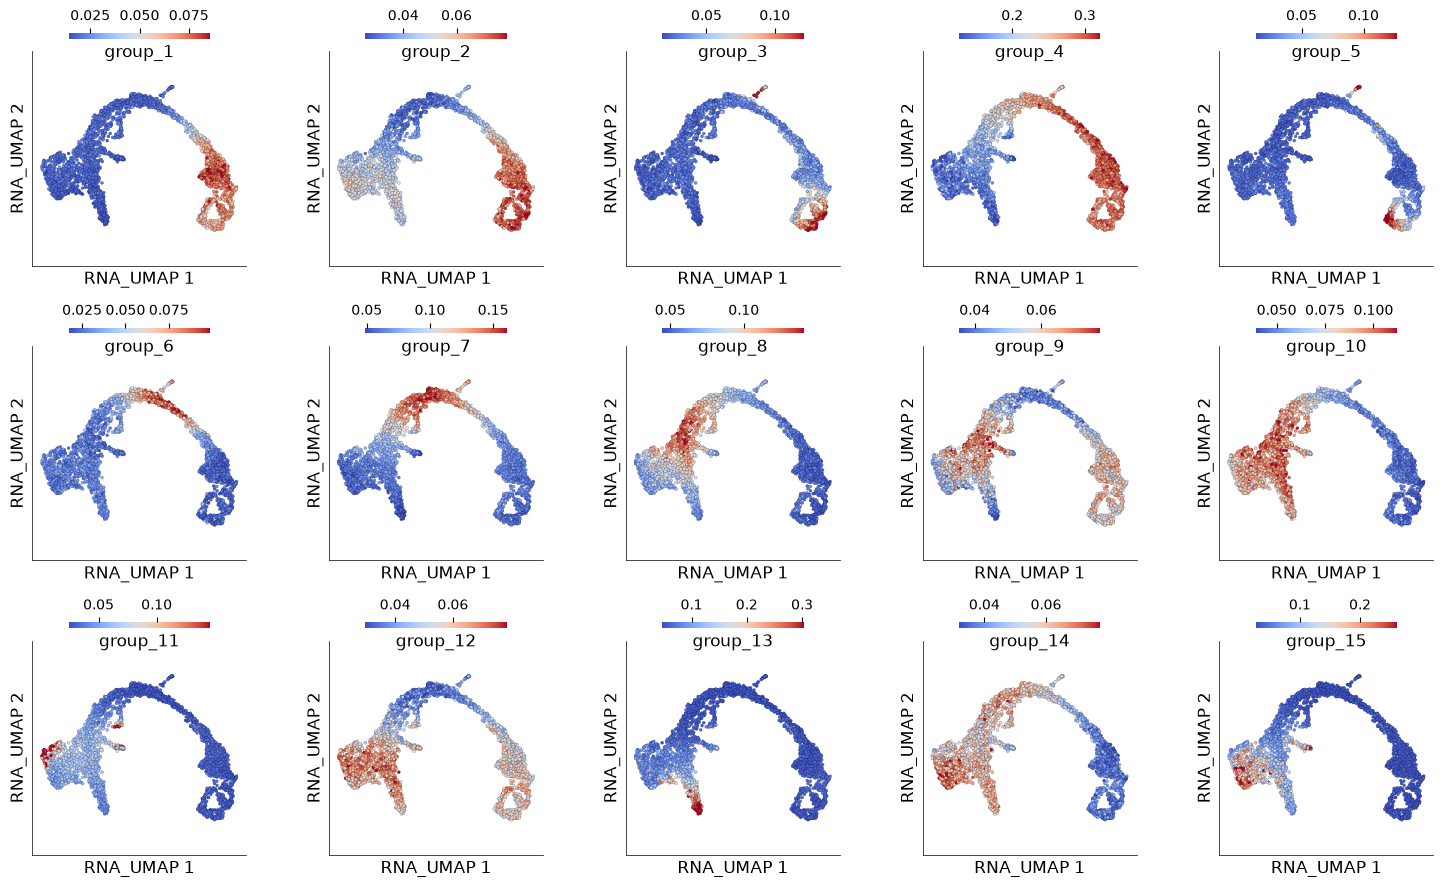

time: 9.13 s (started: 2026-07-17 01:37:06 +02:00)


In [23]:
n_clusters = 15
ds.plot_layout(
    from_assay="PTIME_MODULES",
    layout_key="RNA_UMAP",
    color_by=[f"group_{i}" for i in range(1, n_clusters + 1)],
    width=3,
    height=3,
    point_size=5,
    n_columns=5,
    cmap="coolwarm",
)

In [24]:
# Running marker search
ds.run_marker_search(group_key="RNA_cluster")

Saved marker results to RNA/markers/I__RNA_cluster in 0.8s (12 clusters, layout=compact_v2)



time: 2.9 s (started: 2026-07-17 01:37:15 +02:00)


In [25]:
cell_cluster_markers = ds.get_markers(
    group_key="RNA_cluster",
    group_id="8",
).feature_name

cell_cluster_markers.head()

0        Ins2
1         Npy
2       Sytl4
3    Arhgap36
4     Tmem215
Name: feature_name, dtype: object

time: 380 ms (started: 2026-07-17 01:37:18 +02:00)


In [26]:
ptime_feat_clusts = ds.RNA.feats.to_pandas_dataframe(
    columns=["names", "pseudotime_clusters"]
)

beta_marker_names = set(cell_cluster_markers)
assigned = ptime_feat_clusts[ptime_feat_clusts.pseudotime_clusters != -1]
module_overlap = assigned.groupby("pseudotime_clusters")["names"].apply(
    lambda names: len(set(names) & beta_marker_names)
)
beta_module = int(module_overlap.idxmax())
beta_module

13

time: 153 ms (started: 2026-07-17 01:37:18 +02:00)


In [27]:
ptime_based_markers = ptime_feat_clusts.names[
    ptime_feat_clusts.pseudotime_clusters == beta_module
]
ptime_based_markers.head()

14            Vcpip1
25             Tram1
87             Uggt1
112           Lonrf2
242    4933417E11Rik
Name: names, dtype: object

time: 8.62 ms (started: 2026-07-17 01:37:18 +02:00)


In [28]:
# Number of genes captured by each approach
ptime_based_markers.shape, cell_cluster_markers.shape

((900,), (90,))

time: 8.1 ms (started: 2026-07-17 01:37:18 +02:00)


In [29]:
# Number of genes shared by both approaches, compared by gene name
len(set(ptime_based_markers) & set(cell_cluster_markers))

79

time: 5.77 ms (started: 2026-07-17 01:37:18 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


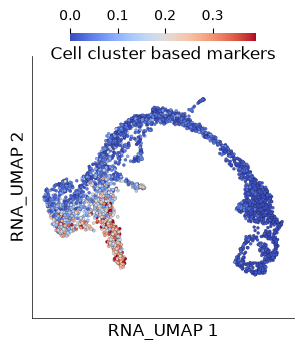

time: 2.24 s (started: 2026-07-17 01:37:18 +02:00)


In [30]:
name_to_idx = dict(zip(ptime_feat_clusts.names, ptime_feat_clusts.index))
cell_only = sorted(
    (set(cell_cluster_markers) - set(ptime_based_markers)) & set(name_to_idx)
)
cell_only_idx = sorted(name_to_idx[name] for name in cell_only)
ds.cells.insert(
    column_name="Cell cluster based markers",
    values=ds.RNA.normed(feat_idx=cell_only_idx).mean(axis=1).compute(),
    overwrite=True,
)

ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by="Cell cluster based markers",
    width=4,
    height=4,
    point_size=5,
    n_columns=5,
    cmap="coolwarm",
)

/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


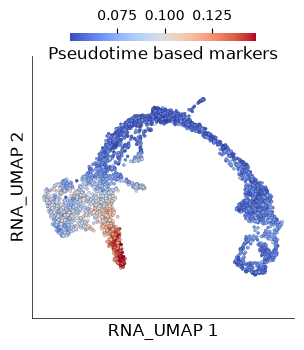

time: 2.13 s (started: 2026-07-17 01:37:21 +02:00)


In [31]:
ptime_only = sorted(
    (set(ptime_based_markers) - set(cell_cluster_markers)) & set(name_to_idx)
)
ptime_only_idx = sorted(name_to_idx[name] for name in ptime_only)
ds.cells.insert(
    column_name="Pseudotime based markers",
    values=ds.RNA.normed(feat_idx=ptime_only_idx).mean(axis=1).compute(),
    overwrite=True,
)

ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by="Pseudotime based markers",
    width=4,
    height=4,
    point_size=5,
    n_columns=5,
    cmap="coolwarm",
)